In [9]:
# imports and such
from pathlib import Path
from utils import load_plastchem, extract_feature_vecs, calculate_mfps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.cluster import KMeans

In [2]:
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")

In [3]:
print(pcc)

Index(['Identifiers_plastchem_ID', 'Identifiers_cas', 'Identifiers_cas_fixed',
       'Identifiers_identified_by', 'Identifiers_pubchem_cid',
       'Identifiers_pubchem_name', 'Identifiers_iupac_name',
       'Properties_molecular_formula', 'Properties_molecular_weight',
       'Properties_canonical_smiles',
       ...
       'Information_sources_in_fccmigex', 'Information_sources_in_litchem',
       'Information_sources_in_plasticmap',
       'Information_sources_original_name_aurisano',
       'Information_sources_original_name_cpp',
       'Information_sources_original_name_echa',
       'Information_sources_original_name_fcc',
       'Information_sources_original_name_fccmigex',
       'Information_sources_original_name_litchem',
       'Information_sources_original_name_plasticmap'],
      dtype='object', length=230)


### ToDo
- calculate fingerprints and then see if those help with the PCA
- find some way to get words?? into PCA → put as numeric label maybe (way to group them)

In [4]:
# cluster data on all information → extract feature vectures by PCA
# some of the data is discrete, other continous → what do i do

# fv = extract_feature_vecs(plast_chem, [('Properties_molecular_weight'), ('Properties_exact_mass'), ('Properties_monoisotopic_mass'),
#                                    ('Properties_tpsa'), ('Properties_complexity')], n=3)

# fig = plt.figure(figsize=(9,6))
# ax = fig.add_subplot(projection='3d')
# ax.scatter(fv[:,0], fv[:,1], fv[:,2], s=10)
# ax.set_xlabel('PCA dimension 1')
# ax.set_ylabel('PCA dimension 2')
# ax.set_zlabel('PCA dimension 3')
# plt.show()

In [5]:
calculate_mfps(plast_chem, 'Properties_canonical_smiles')

[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:28] WARNING: not removing hydrogen atom without neighbors
[17:25:29] WARNING: not removing hydrogen atom without neighbors
[17:25:29] WARNING: not removing hydrogen atom without neighbors
[17:25:29] WARNING: not removing hydrogen atom without neighbors
[17:25:29] Explicit valence for atom # 1 Br, 2, is greater than permitted
[17:25:29] WARNING: not removing hydrogen atom without neighbors
[17:25:29] WARNING: not removing hydrogen atom without neighbors
[17:25:29] WARNI

In [6]:
print(plast_chem['Properties_morgan_fingerprint'])

0        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                               ...                        
17931                                                 None
17932                                                 None
17933                                                 None
17934                                                 None
17935                                                 None
Name: Properties_morgan_fingerprint, Length: 17936, dtype: object


In [14]:
valid_fps = plast_chem['Properties_morgan_fingerprint'].dropna()


X = np.vstack(valid_fps.values) # list into 2d arr

print(X.shape)
# (n_molecules, n_bits)
tsne = TSNE(n_components=3, random_state=1)
reduced_data = tsne.fit_transform(X)

(12951, 2048)


/tmp/ipykernel_367672/3408925233.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


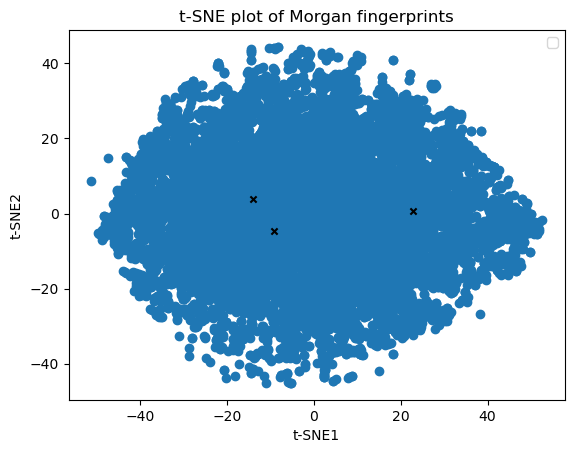

In [15]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(reduced_data)

# Plot scatter plot of reduced data with cluster labels
# do this by classes 
plt.scatter(reduced_data[:,0], reduced_data[:,1])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='black', marker='x', s=20)
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.title('t-SNE plot of Morgan fingerprints')
plt.legend()
plt.show()

In [ ]:
# plan: extract feature vecs on PCA, then cluster based on commodity plastics